# CICIDS-2017 — VoIP/Network Anomaly Detection
**Author:** R Yadunath Reddy, IIIT Kottayam

## Model Used
- **MLP (Multi-Layer Perceptron)**
- **1D-CNN (Convolutional Nueral Network)**


## CICIDS-2017 Dataset
The dataset contains 80 features extracted from packet flows, covering attacks such as DoS, DDoS, brute force, infiltration, botnet, and web-based attacks across 15 labeled categories.

**VoIP relevance:** DoS Hulk, DoS Slowhttptest, DoS slowloris, and DDoS categories are
directly analogous to SIP INVITE flooding and RTP flooding attacks in VoIP networks.

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn tensorflow imbalanced-learn keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00


## 1. Imports & Config

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, glob
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print(f'TensorFlow : {tf.__version__}')
print('Imports OK ✓')

TensorFlow : 2.19.0
Imports OK ✓


## 2. Load CICIDS-2017 Data

CICIDS-2017 comes as multiple CSV files (one per day). This cell loads all of them.

In [ ]:
# ── UPDATE THIS PATH ──────────────────────────────────────────
DATA_PATH = '/content/CICIDS2017/'   # folder containing the CSV files
# ─────────────────────────────────────────────────────────────

csv_files = glob.glob(os.path.join(DATA_PATH, '*.csv'))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {os.path.basename(f)}')

# Load and concatenate all days
dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f, low_memory=False)
    dfs.append(df_tmp)
    print(f'  Loaded {os.path.basename(f)}: {len(df_tmp):,} rows')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal records: {len(df):,}')
print(f'Total columns: {len(df.columns)}')

Found 8 CSV files:
  Wednesday-workingHours.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loaded Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows
  Loaded Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  Loaded Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows

Total records: 2,830,743
Total columns: 79


## 3. EDA & Preprocessing

Label column: "Label"

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

VoIP-relevant records: 2,655,751
Label
BENIGN              2273097
DoS Hulk             231073
DDoS                 128027
DoS GoldenEye         10293
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Name: count, dtype: int64


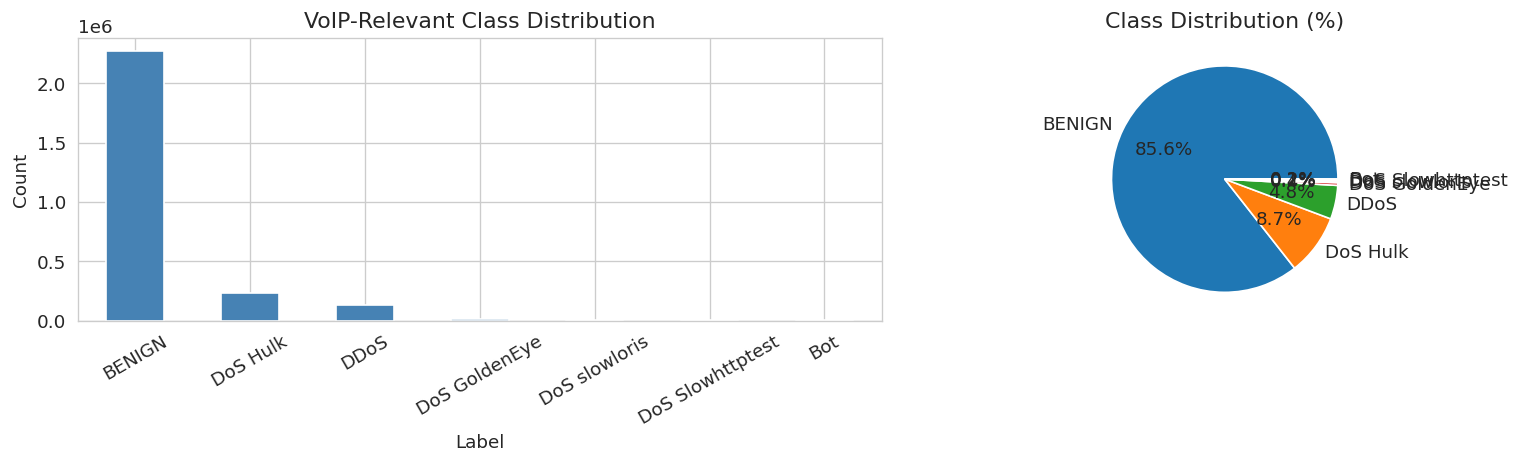

In [ ]:
# ── Standardize column names ───────────────────────────────────
df.columns = df.columns.str.strip()

# Find label column (differs slightly between CICIDS versions)
label_col = [c for c in df.columns if 'label' in c.lower()][0]
print(f'Label column: "{label_col}"')
print(f'\nClass distribution:')
print(df[label_col].value_counts())

# ── Filter for VoIP-relevant attack types ─────────────────────
# Keep: BENIGN + DoS/DDoS variants (analogous to SIP flooding)
# You can also keep all attacks for a full multi-class experiment
VOIP_RELEVANT = [
    'BENIGN',
    'DoS Hulk', 'DoS slowloris', 'DoS Slowhttptest', 'DoS GoldenEye',
    'DDoS',
    'Bot'   # Botnet ≈ SPIT bots in VoIP
]

df_voip = df[df[label_col].isin(VOIP_RELEVANT)].copy()
print(f'\nVoIP-relevant records: {len(df_voip):,}')
print(df_voip[label_col].value_counts())

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
vc = df_voip[label_col].value_counts()
vc.plot(kind='bar', ax=axes[0], color='steelblue', rot=30)
axes[0].set_title('VoIP-Relevant Class Distribution')
axes[0].set_ylabel('Count')

vc_pct = df_voip[label_col].value_counts(normalize=True) * 100
axes[1].pie(vc_pct.values, labels=vc_pct.index, autopct='%1.1f%%')
axes[1].set_title('Class Distribution (%)')
plt.tight_layout(); plt.show()

In [ ]:
# ── Feature columns ───────────────────────────────────────────
feature_cols = [c for c in df_voip.columns if c != label_col]

X = df_voip[feature_cols].copy()
y_raw = df_voip[label_col].copy()

# ── Clean ──────────────────────────────────────────────────────
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(numeric_only=True), inplace=True)

# Drop zero-variance columns
zero_var = X.columns[X.std() == 0]
X.drop(columns=zero_var, inplace=True)
print(f'Dropped {len(zero_var)} zero-variance columns')
print(f'Remaining features: {X.shape[1]}')

# ── Encode labels (binary: 0=BENIGN, 1=ATTACK) ────────────────
y_binary = (y_raw != 'BENIGN').astype(int)
print(f'\nBinary label distribution:')
print(f'  Normal (0): {(y_binary==0).sum():,}')
print(f'  Attack (1): {(y_binary==1).sum():,}')

# ── Feature Selection: top-K by mutual information ────────────
# Reduces dimensionality, speeds up training, reduces overfitting
K_FEATURES = 40   # top 40 out of ~80 features
selector = SelectKBest(mutual_info_classif, k=K_FEATURES)

# Fit on a sample for speed (mutual_info is slow on 2M+ rows)
sample_idx = np.random.choice(len(X), min(50000, len(X)), replace=False)
selector.fit(X.iloc[sample_idx], y_binary.iloc[sample_idx])
selected_features = X.columns[selector.get_support()].tolist()
print(f'\nSelected {len(selected_features)} features via mutual information')

X = X[selected_features]

# ── Train / Val / Test split ───────────────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y_binary, test_size=0.15, stratify=y_binary, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=SEED)

print(f'\nSplit: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')

# ── Scale (fit ONLY on train) ──────────────────────────────────
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── SMOTE on training set only ────────────────────────────────
# Only apply if imbalance ratio > 10:1
ratio = (y_train==0).sum() / (y_train==1).sum()
print(f'\nClass ratio (normal:attack) = {ratio:.1f}:1')
if ratio > 10:
    sm = SMOTE(random_state=SEED)
    X_train_s, y_train = sm.fit_resample(X_train_s, y_train)
    print(f'After SMOTE: {len(X_train_s):,} samples')
else:
    print('Class balance acceptable — SMOTE not applied')

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print('Preprocessing complete ✓')

Dropped 8 zero-variance columns
Remaining features: 70

Binary label distribution:
  Normal (0): 2,273,097
  Attack (1): 382,654

Selected 40 features via mutual information

Split: Train=1,860,087 | Val=397,301 | Test=398,363

Class ratio (normal:attack) = 5.9:1
Class balance acceptable — SMOTE not applied
Preprocessing complete ✓


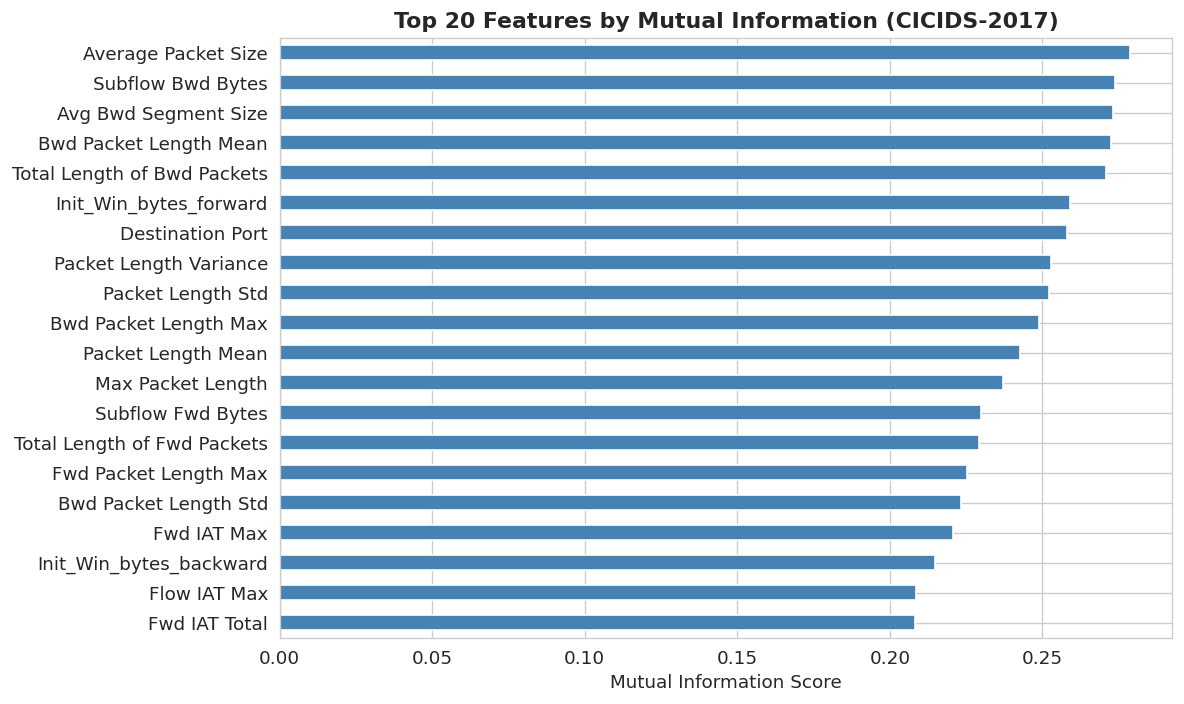

In [ ]:
# ── Feature importance via mutual info (visualization) ─────────
mi_scores = selector.scores_[selector.get_support()]
fi = pd.Series(mi_scores, index=selected_features).nlargest(20)

plt.figure(figsize=(10, 6))
fi.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Features by Mutual Information (CICIDS-2017)', fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.tight_layout(); plt.show()

---
## MLP (Multi-Layer Perceptron)

### How It Works
An MLP is a fully connected feedforward neural network. Each neuron in a layer receives
ALL outputs from the previous layer, applies a weighted sum + bias, then passes through
an activation function (ReLU for hidden layers, Sigmoid for binary output).

**Architecture used here:**
```
Input(40) → Dense(256, ReLU) → BN → Dropout(0.3)
          → Dense(128, ReLU) → BN → Dropout(0.3)
          → Dense(64,  ReLU) → BN → Dropout(0.2)
          → Dense(1, Sigmoid)
```
**BatchNormalization** normalizes layer inputs — stabilizes and speeds up training.
**Dropout** randomly disables neurons during training — prevents overfitting.

**Why MLP for CICIDS?** Captures complex nonlinear feature interactions across the 40 selected
flow features. The features are pre-aggregated per flow (not raw packets) so sequential
modeling (LSTM/GRU) gives no additional benefit here.

In [ ]:
def build_mlp(input_dim, l2_reg=1e-4):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,),
              kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu',
              kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ], name='MLP_Classifier')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

mlp = build_mlp(X_train_s.shape[1])
mlp.summary()

Model: "MLP_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,505 (209.00 KB)

 Trainable params: 52,609 (205.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ── Class weights ─────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))
print(f'Class weights: {cw_dict}')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history_mlp = mlp.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=60,
    batch_size=512,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1
)
print('MLP Training complete ✓')

Class weights: {0: np.float64(0.5841702908655114), 1: np.float64(3.470169134848943)}
Epoch 1/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 77s 20ms/step - accuracy: 0.9654 - loss: 0.1038 - precision: 0.8200 - recall: 0.9732 - val_accuracy: 0.9710 - val_loss: 0.0817 - val_precision: 0.8355 - val_recall: 0.9946 - learning_rate: 0.0010
Epoch 2/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step - accuracy: 0.9754 - loss: 0.0686 - precision: 0.8617 - recall: 0.9877 - val_accuracy: 0.9770 - val_loss: 0.0644 - val_precision: 0.8655 - val_recall: 0.9953 - learning_rate: 0.0010
Epoch 3/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 83s 20ms/step - accuracy: 0.9761 - loss: 0.0647 - precision: 0.8647 - recall: 0.9892 - val_accuracy: 0.9763 - val_loss: 0.0615 - val_precision: 0.8622 - val_recall: 0.9947 - learning_rate: 0.0010
Epoch 4/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 80s 20ms/step - accuracy: 0.9767 - loss: 0.0622 - precision: 0.8675 - recall: 0.9897 - val_accuracy: 0.9767 - val_loss: 0.0635 - val_precision: 0.8641 - val_re

Optimal threshold (max F1): 0.64
F1 at optimal threshold   : 0.9722


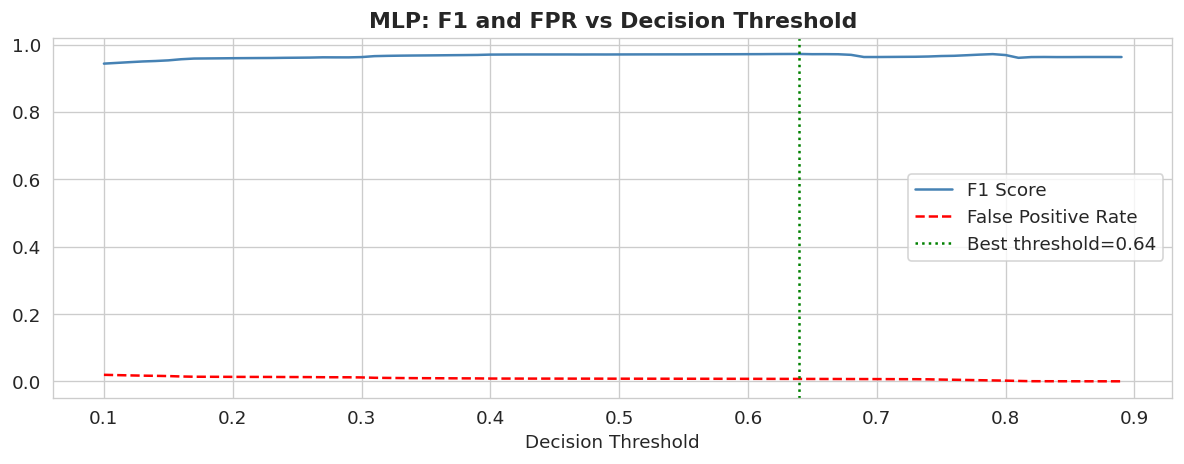

In [ ]:
# ── Threshold Tuning ──────────────────────────────────────────
# Default threshold is 0.5 but tuning on validation set
# can significantly reduce false positives
y_proba_mlp_val = mlp.predict(X_val_s, verbose=0).ravel()

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (y_proba_mlp_val >= t).astype(int),
                        zero_division=0) for t in thresholds]
fpr_scores = []
for t in thresholds:
    pred = (y_proba_mlp_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    fpr_scores.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

# Best threshold = maximizes F1
best_t_mlp = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold (max F1): {best_t_mlp:.2f}')
print(f'F1 at optimal threshold   : {max(f1_scores):.4f}')

# Plot threshold analysis
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,  label='F1 Score',          color='steelblue')
plt.plot(thresholds, fpr_scores, label='False Positive Rate', color='red', linestyle='--')
plt.axvline(best_t_mlp, color='green', linestyle=':', label=f'Best threshold={best_t_mlp:.2f}')
plt.xlabel('Decision Threshold')
plt.title('MLP: F1 and FPR vs Decision Threshold', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
y_proba_mlp = mlp.predict(X_test_s, verbose=0).ravel()
y_pred_mlp  = (y_proba_mlp >= best_t_mlp).astype(int)

def evaluate(y_true, y_pred, y_proba, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f'\n{'='*52}')
    print(f'  {name} — Test Results')
    print(f'{'='*52}')
    print(f'  Accuracy            : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision           : {prec:.4f}')
    print(f'  Recall              : {rec:.4f}')
    print(f'  F1-Score            : {f1:.4f}')
    print(f'  ROC-AUC             : {auc:.4f}')
    print(f'  False Positive Rate : {fpr:.4f} ({fpr*100:.2f}%)')
    print(f'  TP={tp} | FP={fp} | TN={tn} | FN={fn}')
    return dict(model=name, accuracy=acc, precision=prec,
                recall=rec, f1=f1, auc=auc, fpr=fpr)

mlp_metrics = evaluate(y_test, y_pred_mlp, y_proba_mlp, 'MLP')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp,
                             target_names=['Normal', 'Attack']))


  MLP — Test Results
  Accuracy            : 0.9918 (99.18%)
  Precision           : 0.9558
  Recall              : 0.9890
  F1-Score            : 0.9721
  ROC-AUC             : 0.9995
  False Positive Rate : 0.0077 (0.77%)
  TP=56767 | FP=2624 | TN=338341 | FN=631

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    340965
      Attack       0.96      0.99      0.97     57398

    accuracy                           0.99    398363
   macro avg       0.98      0.99      0.98    398363
weighted avg       0.99      0.99      0.99    398363



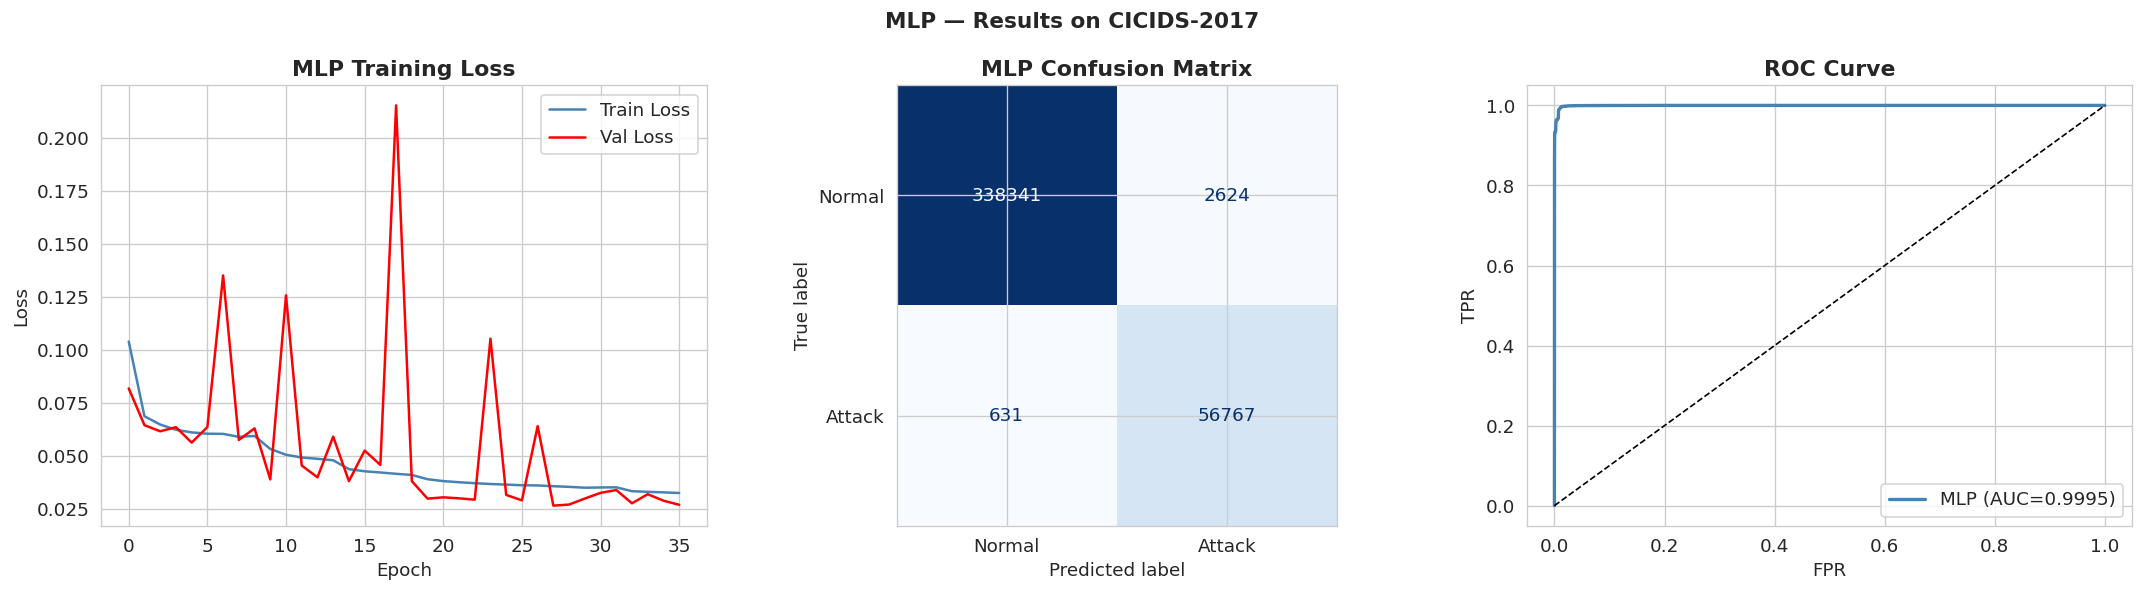

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curves
axes[0].plot(history_mlp.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history_mlp.history['val_loss'], label='Val Loss',   color='red')
axes[0].set_title('MLP Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('MLP Confusion Matrix', fontweight='bold')

# ROC
fpr_m, tpr_m, _ = roc_curve(y_test, y_proba_mlp)
axes[2].plot(fpr_m, tpr_m, color='steelblue', lw=2,
             label=f"MLP (AUC={mlp_metrics['auc']:.4f})")
axes[2].plot([0,1],[0,1],'k--', lw=1)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend()

plt.suptitle('MLP — Results on CICIDS-2017', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## MODEL 2: 1D-CNN (1D Convolutional Neural Network)

### How It Works
A 1D-CNN applies convolution filters across the sequence of features, treating the
feature vector as a 1D 'signal'. Each filter learns to detect a local pattern in a
sliding window of features. Multiple filters capture different patterns simultaneously.

**Architecture used here:**
```
Input(40,1) → Conv1D(64, k=3) → BN → MaxPool
            → Conv1D(128, k=3) → BN → MaxPool
            → Conv1D(256, k=3) → BN → GlobalAvgPool
            → Dense(128) → Dropout(0.3)
            → Dense(1, Sigmoid)
```
**Why 1D-CNN for CICIDS?** Research shows CNN with feature selection achieves 99% accuracy
on network intrusion datasets. 1D-CNN captures **co-occurring feature patterns**
(e.g., high packet rate + large payload + low IAT) that indicate flooding attacks — directly
analogous to SIP INVITE flooding patterns in VoIP.

In [ ]:
# ── Reshape for CNN: (samples, features, 1) ───────────────────
X_train_cnn = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
X_val_cnn   = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)
X_test_cnn  = X_test_s.reshape(X_test_s.shape[0], X_test_s.shape[1], 1)

def build_cnn(input_shape, l2_reg=1e-4):
    model = Sequential([
        # Block 1
        Conv1D(64, kernel_size=3, activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(l2_reg),
               input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 2
        Conv1D(128, kernel_size=3, activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 3
        Conv1D(256, kernel_size=3, activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(l2_reg)),
        BatchNormalization(),
        GlobalAveragePooling1D(),

        # Classifier head
        Dense(128, activation='relu',
              kernel_regularizer=regularizers.l2(l2_reg)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='CNN_1D_Classifier')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

cnn = build_cnn((X_train_cnn.shape[1], 1))
cnn.summary()

Model: "CNN_1D_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,337 (618.50 KB)

 Trainable params: 157,441 (615.00 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ── Class weights ─────────────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(cw))
print(f'Class weights: {cw_dict}')

cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=60,
    batch_size=512,
    class_weight=cw_dict,
    callbacks=cnn_callbacks,
    verbose=1
)
print('CNN Training complete ✓')

Class weights: {0: np.float64(0.5841702908655114), 1: np.float64(3.470169134848943)}
Epoch 1/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 779s 213ms/step - accuracy: 0.9817 - loss: 0.0689 - precision: 0.8960 - recall: 0.9875 - val_accuracy: 0.9811 - val_loss: 0.0921 - val_precision: 0.8894 - val_recall: 0.9921 - learning_rate: 0.0010
Epoch 2/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 757s 208ms/step - accuracy: 0.9909 - loss: 0.0353 - precision: 0.9460 - recall: 0.9939 - val_accuracy: 0.8571 - val_loss: 6.7929 - val_precision: 0.9878 - val_recall: 0.0085 - learning_rate: 0.0010
Epoch 3/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 767s 211ms/step - accuracy: 0.9931 - loss: 0.0271 - precision: 0.9579 - recall: 0.9961 - val_accuracy: 0.9511 - val_loss: 0.4167 - val_precision: 0.9936 - val_recall: 0.6648 - learning_rate: 0.0010
Epoch 4/60
3633/3633 ━━━━━━━━━━━━━━━━━━━━ 800s 210ms/step - accuracy: 0.9937 - loss: 0.0241 - precision: 0.9613 - recall: 0.9968 - val_accuracy: 0.9617 - val_loss: 0.1435 - val_precision: 0.9951 

CNN Optimal threshold: 0.55
CNN F1 at threshold  : 0.9912


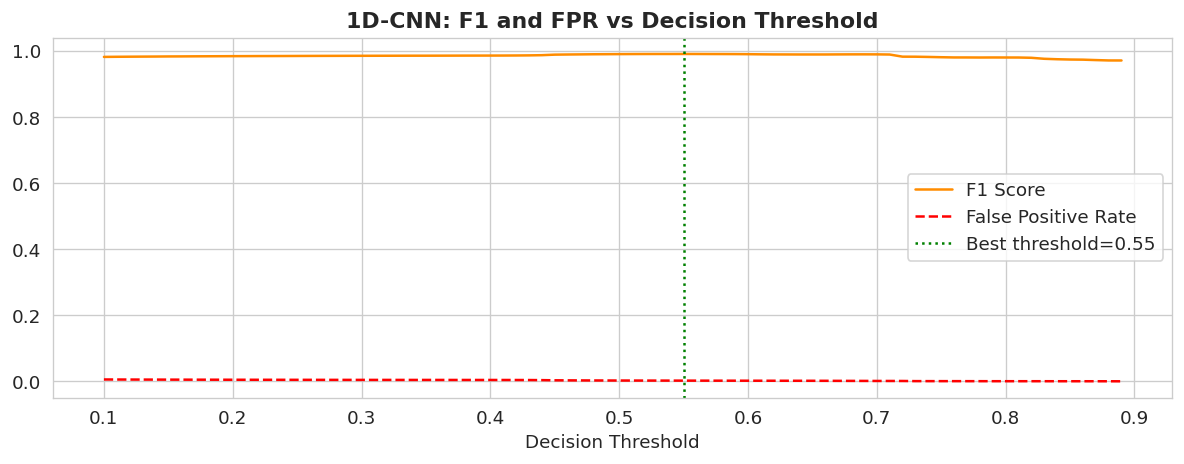

In [ ]:
# ── Threshold Tuning for CNN ───────────────────────────────────
y_proba_cnn_val = cnn.predict(X_val_cnn, verbose=0).ravel()

thresholds = np.arange(0.1, 0.9, 0.01)

f1_cnn  = [f1_score(y_val, (y_proba_cnn_val >= t).astype(int),
                    zero_division=0) for t in thresholds]
fpr_cnn = []
for t in thresholds:
    pred = (y_proba_cnn_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    fpr_cnn.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

best_t_cnn = thresholds[np.argmax(f1_cnn)]
print(f'CNN Optimal threshold: {best_t_cnn:.2f}')
print(f'CNN F1 at threshold  : {max(f1_cnn):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_cnn,  label='F1 Score',           color='darkorange')
plt.plot(thresholds, fpr_cnn, label='False Positive Rate', color='red', linestyle='--')
plt.axvline(best_t_cnn, color='green', linestyle=':',
            label=f'Best threshold={best_t_cnn:.2f}')
plt.xlabel('Decision Threshold')
plt.title('1D-CNN: F1 and FPR vs Decision Threshold', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
y_proba_cnn = cnn.predict(X_test_cnn, verbose=0).ravel()
y_pred_cnn  = (y_proba_cnn >= best_t_cnn).astype(int)

cnn_metrics = evaluate(y_test, y_pred_cnn, y_proba_cnn, '1D-CNN')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_cnn,
                             target_names=['Normal', 'Attack']))


  1D-CNN — Test Results
  Accuracy            : 0.9971 (99.71%)
  Precision           : 0.9835
  Recall              : 0.9969
  F1-Score            : 0.9902
  ROC-AUC             : 0.9999
  False Positive Rate : 0.0028 (0.28%)
  TP=57222 | FP=961 | TN=340004 | FN=176

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    340965
      Attack       0.98      1.00      0.99     57398

    accuracy                           1.00    398363
   macro avg       0.99      1.00      0.99    398363
weighted avg       1.00      1.00      1.00    398363



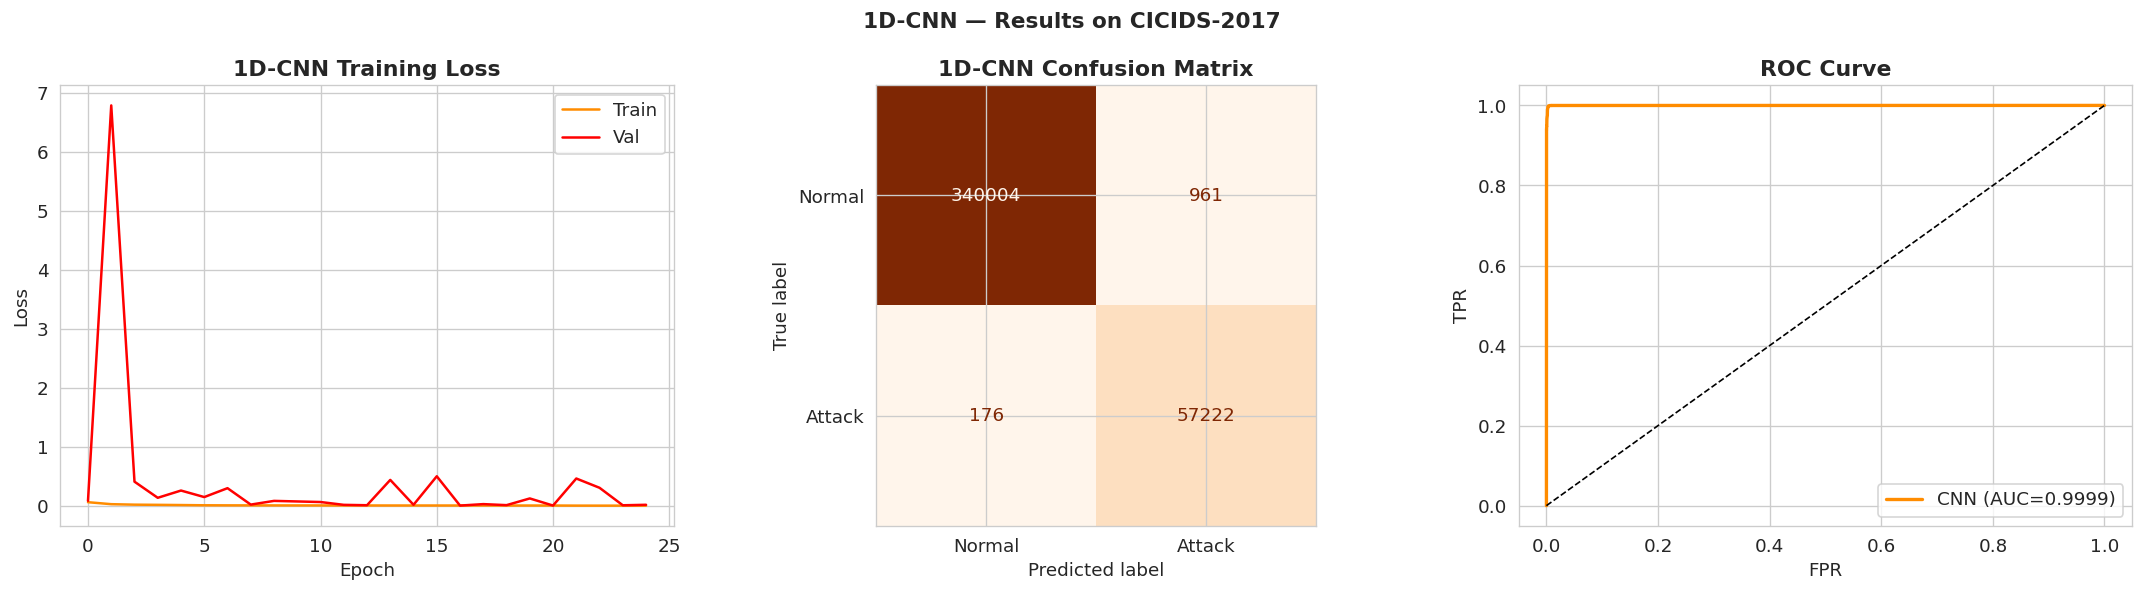

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_cnn.history['loss'],     label='Train', color='darkorange')
axes[0].plot(history_cnn.history['val_loss'], label='Val',   color='red')
axes[0].set_title('1D-CNN Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=['Normal', 'Attack']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('1D-CNN Confusion Matrix', fontweight='bold')

fpr_c, tpr_c, _ = roc_curve(y_test, y_proba_cnn)
axes[2].plot(fpr_c, tpr_c, color='darkorange', lw=2,
             label=f"CNN (AUC={cnn_metrics['auc']:.4f})")
axes[2].plot([0,1],[0,1],'k--', lw=1)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve', fontweight='bold'); axes[2].legend()

plt.suptitle('1D-CNN — Results on CICIDS-2017', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5. Cross-Model Comparison


=== FINAL MODEL COMPARISON — CICIDS-2017 ===
        accuracy  precision  recall      f1     auc     fpr
model                                                      
MLP       0.9918     0.9558  0.9890  0.9721  0.9995  0.0077
1D-CNN    0.9971     0.9835  0.9969  0.9902  0.9999  0.0028


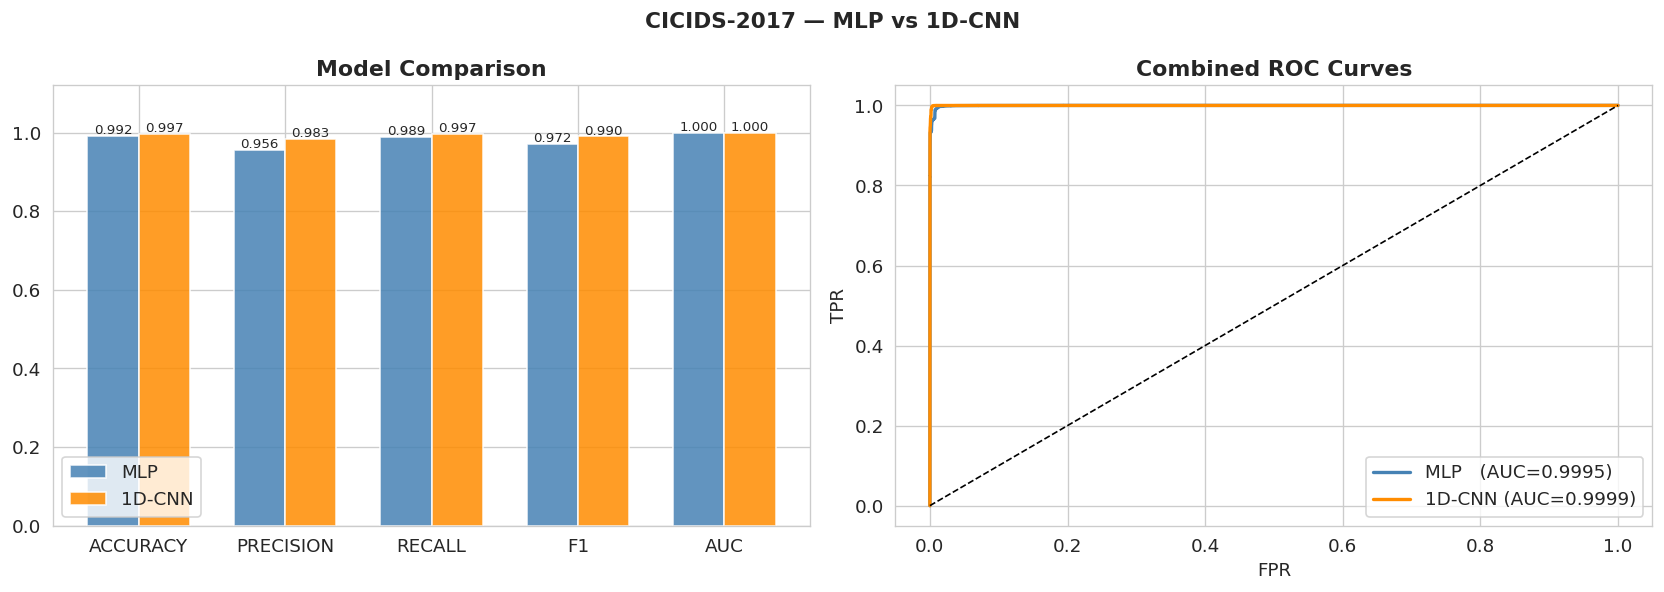

In [ ]:
results = pd.DataFrame([mlp_metrics, cnn_metrics]).set_index('model')
print('\n=== FINAL MODEL COMPARISON — CICIDS-2017 ===')
print(results.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
metrics_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics_plot))
w = 0.35
colors = ['steelblue', 'darkorange']
for i, (model, color) in enumerate(zip(results.index, colors)):
    vals = [results.loc[model, m] for m in metrics_plot]
    bars = axes[0].bar(x + i*w, vals, w, label=model, color=color, alpha=0.85)
    for b, v in zip(bars, vals):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                     f'{v:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x + w/2)
axes[0].set_xticklabels([m.upper() for m in metrics_plot])
axes[0].set_ylim(0, 1.12)
axes[0].set_title('Model Comparison', fontweight='bold')
axes[0].legend()

# Combined ROC
axes[1].plot(fpr_m, tpr_m, color='steelblue', lw=2,
             label=f"MLP   (AUC={mlp_metrics['auc']:.4f})")
axes[1].plot(fpr_c, tpr_c, color='darkorange', lw=2,
             label=f"1D-CNN (AUC={cnn_metrics['auc']:.4f})")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Combined ROC Curves', fontweight='bold')
axes[1].legend()

plt.suptitle('CICIDS-2017 — MLP vs 1D-CNN', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. FPR Analysis — Minimizing False Positives

The cell below plots FPR at different thresholds for both models so you can pick
the threshold that gives **< 1% false positive rate** even at some recall cost.

At 1% FPR:
  MLP   recall: 0.9924
  1D-CNN recall: 0.9998


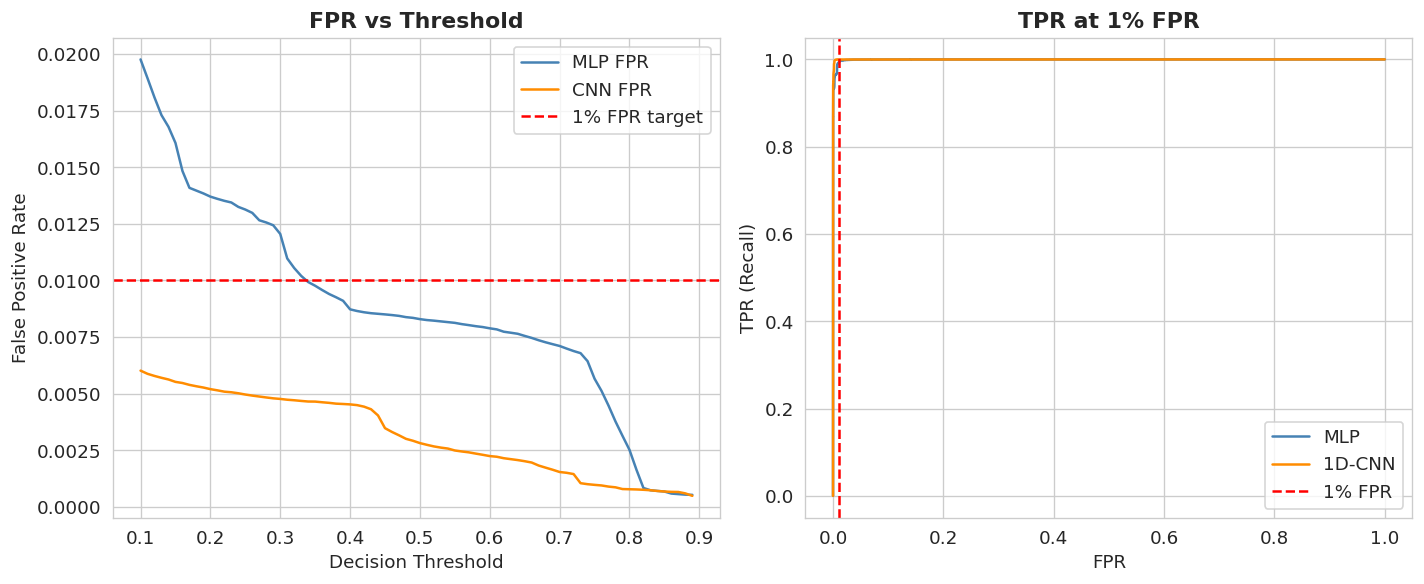

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, fpr_scores, label='MLP FPR',  color='steelblue')
plt.plot(thresholds, fpr_cnn,    label='CNN FPR',  color='darkorange')
plt.axhline(0.01, color='red', linestyle='--', label='1% FPR target')
plt.xlabel('Decision Threshold'); plt.ylabel('False Positive Rate')
plt.title('FPR vs Threshold', fontweight='bold')
plt.legend()

# Recall at 1% FPR
fpr_ml, tpr_ml, thr_ml = roc_curve(y_test, y_proba_mlp)
fpr_cl, tpr_cl, thr_cl = roc_curve(y_test, y_proba_cnn)

plt.subplot(1, 2, 2)
plt.plot(fpr_ml, tpr_ml, label='MLP',   color='steelblue')
plt.plot(fpr_cl, tpr_cl, label='1D-CNN', color='darkorange')
plt.axvline(0.01, color='red', linestyle='--', label='1% FPR')
plt.xlabel('FPR'); plt.ylabel('TPR (Recall)')
plt.title('TPR at 1% FPR', fontweight='bold')
plt.legend()

# Find recall at 1% FPR for each model
idx_m = np.argmin(np.abs(fpr_ml - 0.01))
idx_c = np.argmin(np.abs(fpr_cl - 0.01))
print(f'At 1% FPR:')
print(f'  MLP   recall: {tpr_ml[idx_m]:.4f}')
print(f'  1D-CNN recall: {tpr_cl[idx_c]:.4f}')

plt.tight_layout(); plt.show()